In [40]:
import pandas as pd
import numpy as np
import cv2
import os
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from PIL import Image

In [41]:
import pandas as pd
DATA_PATH = '/kaggle/input/datasets/seifeldeenamr/celeba-dataset/data'

bbox_df = pd.read_csv(f'{DATA_PATH}/list_bbox_celeba.txt', sep=r'\s+', skiprows=1, index_col=0)
bbox_df.reset_index(inplace=True)
bbox_df.rename(columns={'index': 'image_id'}, inplace=True)

IMAGE_FOLDER = f'{DATA_PATH}/img_align_celeba'

print(f"Total images: {len(bbox_df)}")
bbox_df.head()

Total images: 202599


,image_id,x_1,y_1,width,height
0,000001.jpg,95,71,226,313
1,000002.jpg,72,94,221,306
2,000003.jpg,216,59,91,126
3,000004.jpg,622,257,564,781
4,000005.jpg,236,109,120,166


In [42]:
img_name = bbox_df.iloc[0]['image_id']

img_path = os.path.join(IMAGE_FOLDER, img_name)

img = Image.open(img_path)

In [43]:
import os
import cv2

img_name = bbox_df.iloc[0]['image_id']

img_path = os.path.join(IMAGE_FOLDER, img_name)

img = cv2.imread(img_path)

In [44]:
def preprocess_image(img):
    img = cv2.resize(img, (256, 256))
    img = cv2.GaussianBlur(img, (5, 5), 0)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)
    return gray

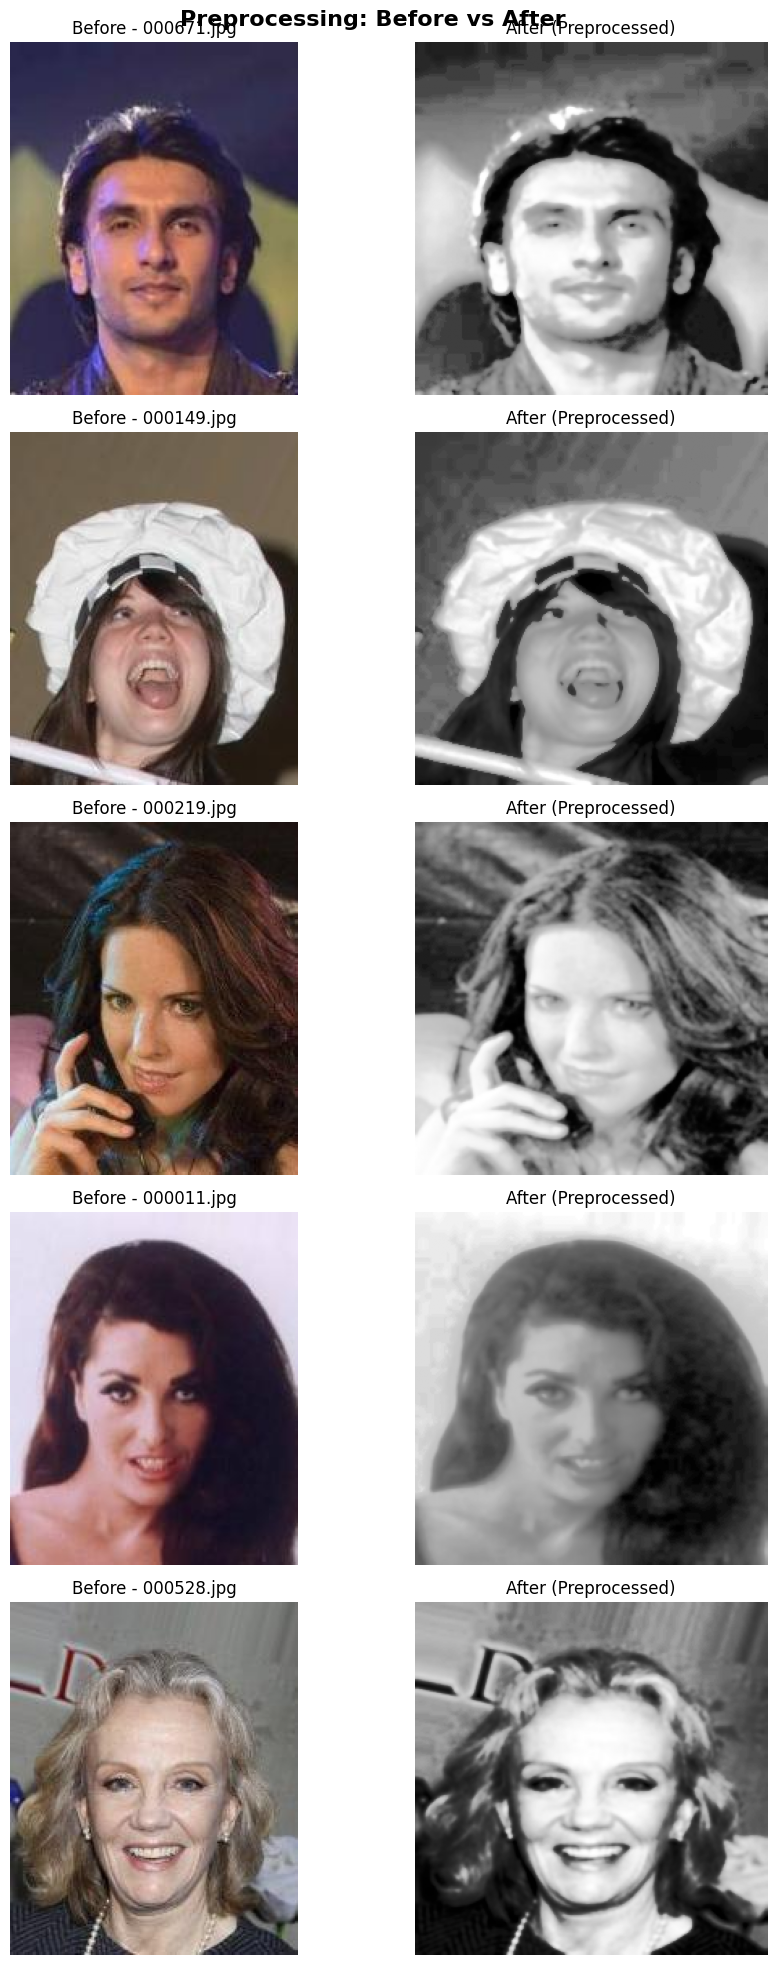

In [45]:
import random

fig, axes = plt.subplots(5, 2, figsize=(10, 20))
fig.suptitle('Preprocessing: Before vs After', fontsize=16, fontweight='bold')

sample_names = random.sample(list(bbox_df[:1000]['image_id']), 5)

for i, image_name in enumerate(sample_names):
    img_path = os.path.join(IMAGE_FOLDER, image_name)
    img = cv2.imread(img_path)
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f'Before - {image_name}')
    axes[i, 0].axis('off')
    
    gray = preprocess_image(img)
    axes[i, 1].imshow(gray, cmap='gray')
    axes[i, 1].set_title('After (Preprocessed)')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()